# JADCO Project - Equinox Collection: Turnkey

**Final Deliverable - Team JFF Podcast**

---

## 1. Problem Introduction and Definition

The objective of this project is to build a predictive model capable of understanding and extrapolating rent growth for the year 2026. To achieve this, we must first define exactly what we are measuring.

To define and understand this metric, it is crucial to first explore and visualize the data.


In [1]:
# Importation of initial data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

listings   = pd.read_csv("data/equinoxe_listings.csv", skipinitialspace=True)
leases     = pd.read_csv("data/equinoxe_lease_history.csv", skipinitialspace=True)
concessions= pd.read_csv("data/equinoxe_concessions.csv", skipinitialspace=True)
asking     = pd.read_csv("data/equinoxe_asking_history.csv", skipinitialspace=True)

# Necessary if columns have padding
listings.columns = listings.columns.str.strip()
leases.columns = leases.columns.str.strip()
concessions.columns = concessions.columns.str.strip()
asking.columns = asking.columns.str.strip()

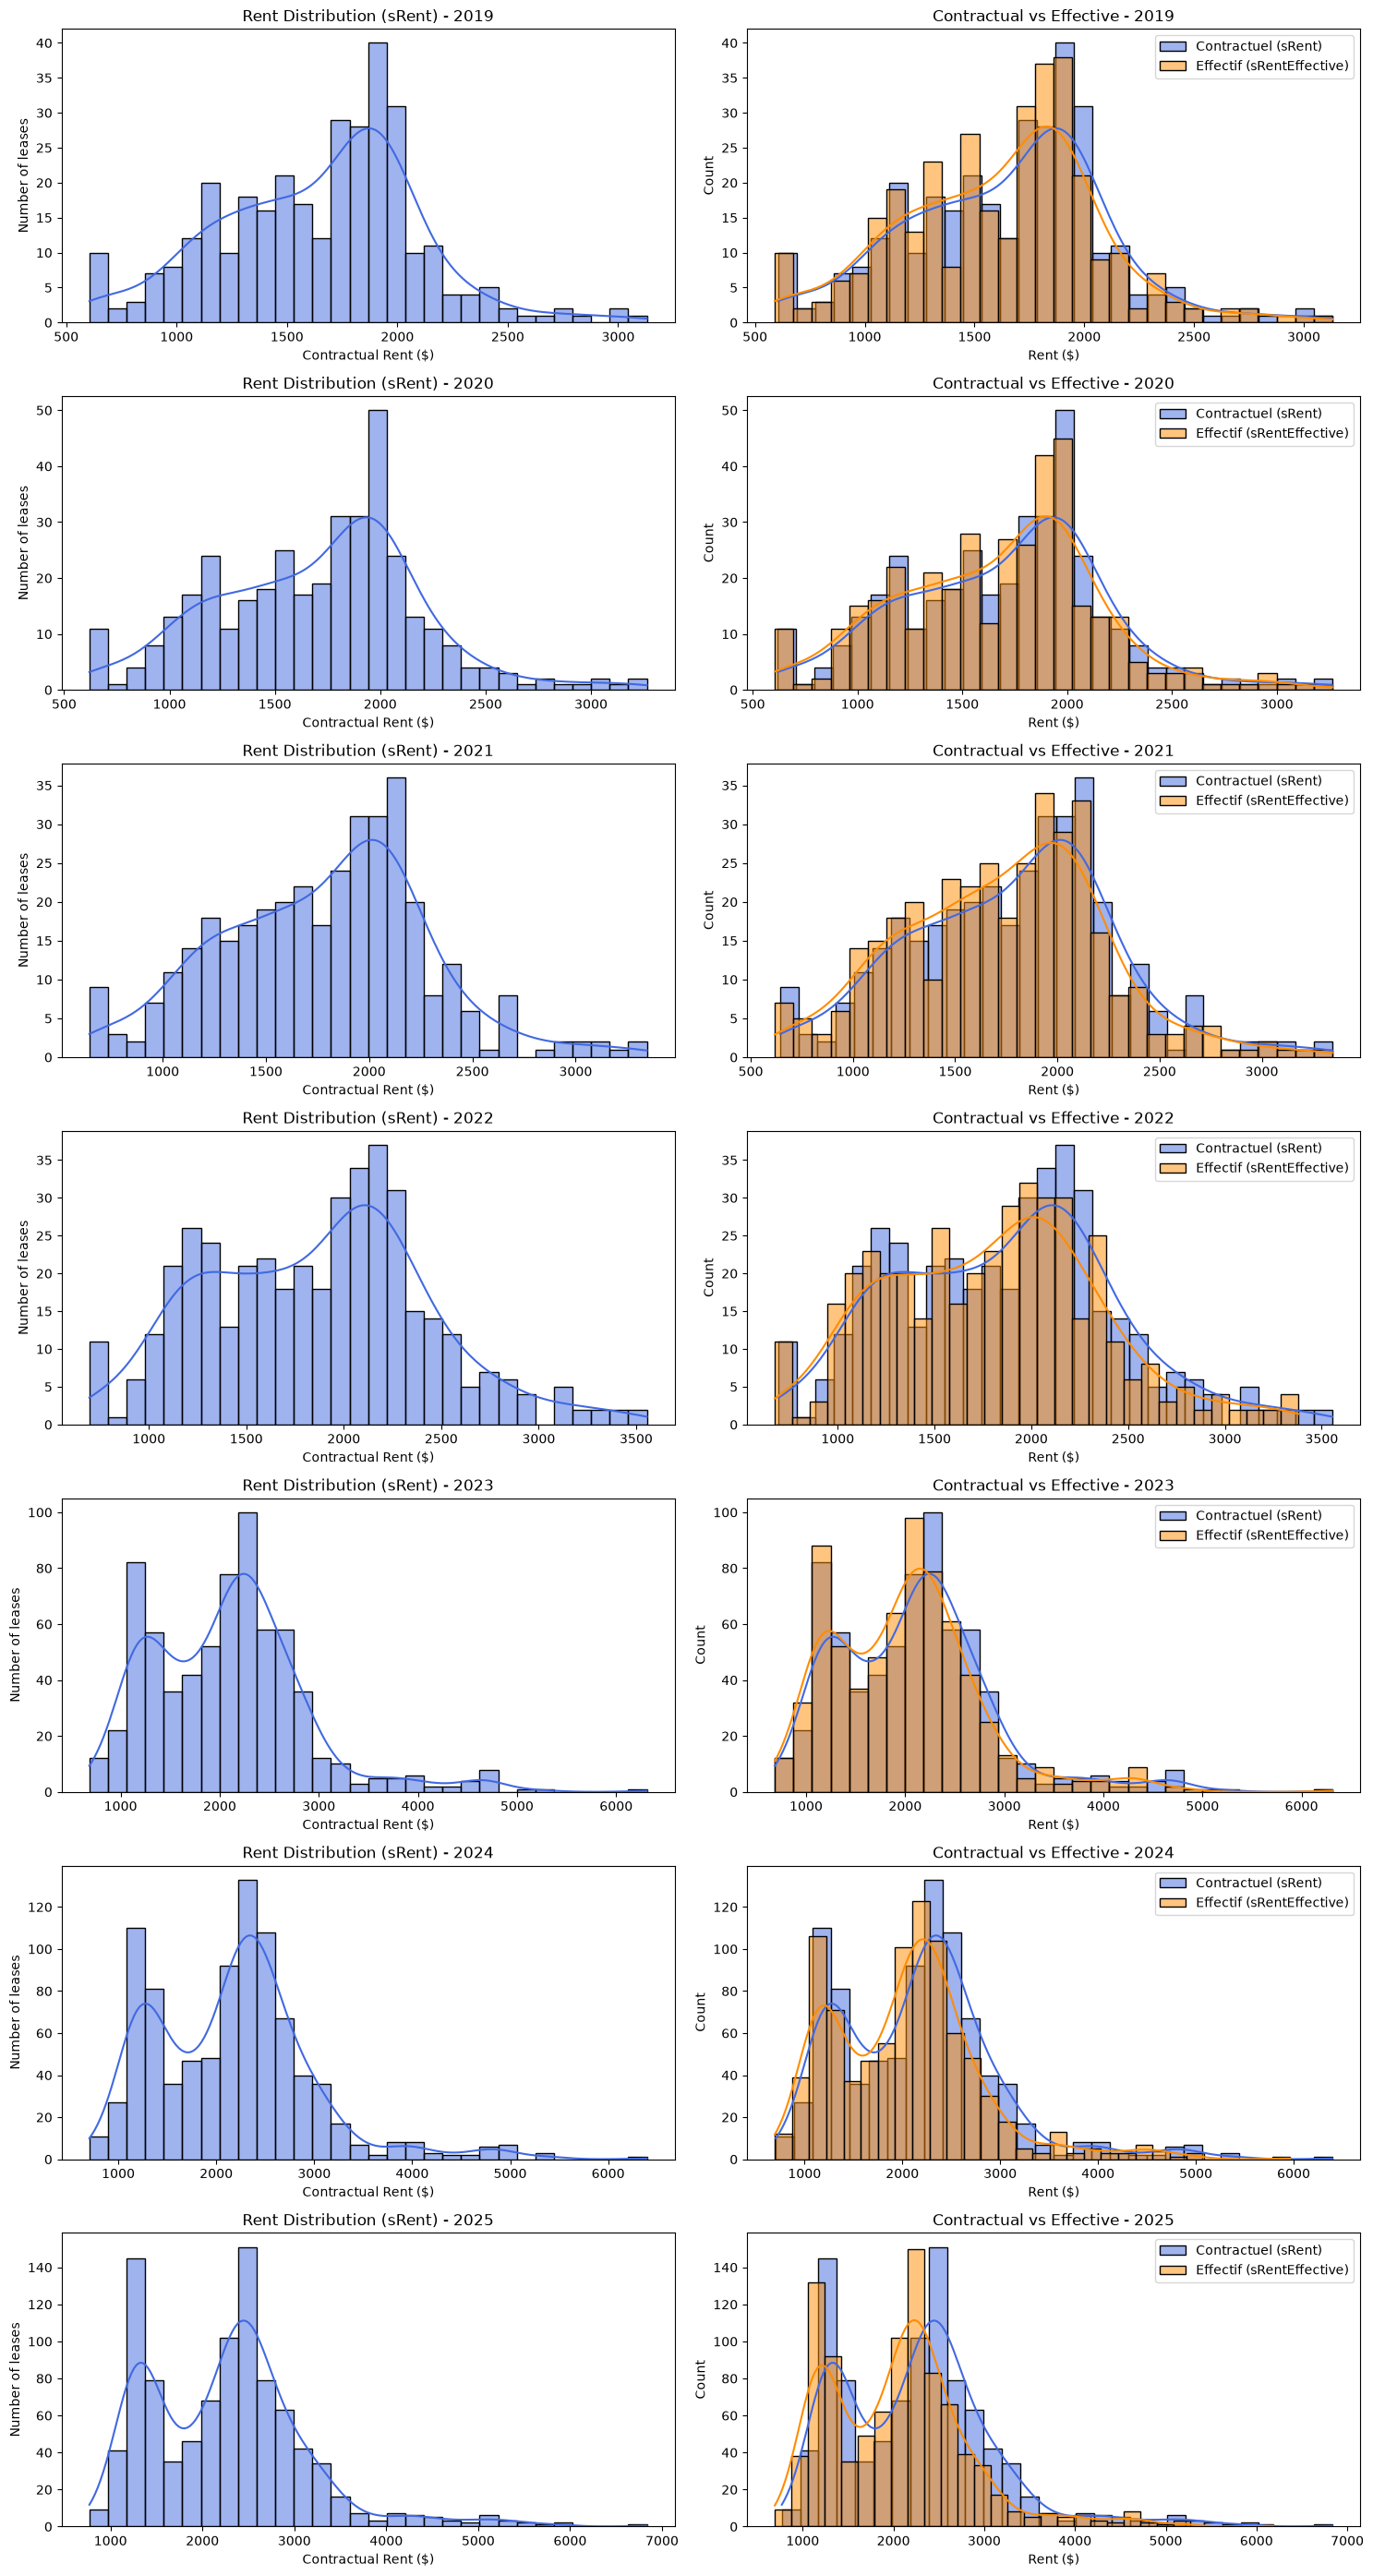

In [2]:
import seaborn as sns

# 1. Ensure the 'year' column exists in the data
leases["sLeaseFrom"] = pd.to_datetime(leases["sLeaseFrom"], errors="coerce")
leases["year"] = leases["sLeaseFrom"].dt.year

# 2. Filter to keep the most relevant years (2019 to 2025)
leases_recent = leases[leases["year"].between(2019, 2025)]
years = sorted(leases_recent["year"].dropna().unique())

# 3. Figure preparation: 1 row per year, 2 columns per row
fig, axes = plt.subplots(nrows=len(years), ncols=2, figsize=(15, 4 * len(years)))

for i, year in enumerate(years):
    df_year = leases_recent[leases_recent["year"] == year]
    
    # --- Colonne de gauche : Histogramme simple du loyer contractuel ---
    sns.histplot(data=df_year, x="sRent", bins=30, kde=True, ax=axes[i, 0], color="royalblue")
    axes[i, 0].set_title(f"Rent Distribution (sRent) - {int(year)}")
    axes[i, 0].set_xlabel("Contractual Rent ($)")
    axes[i, 0].set_ylabel("Number of leases")
    
    # --- Colonne de droite : Comparaison Contractual vs Effective ---
    # Loyer contractuel (en bleu)
    sns.histplot(data=df_year, x="sRent", bins=30, kde=True, ax=axes[i, 1], 
                 color="royalblue", label="Contractuel (sRent)", alpha=0.5)
    # Loyer effectif (en orange)
    sns.histplot(data=df_year, x="sRentEffective", bins=30, kde=True, ax=axes[i, 1], 
                 color="darkorange", label="Effectif (sRentEffective)", alpha=0.5)
    
    axes[i, 1].set_title(f"Contractual vs Effective - {int(year)}")
    axes[i, 1].set_xlabel("Rent ($)")
    axes[i, 1].legend()

# Adjust spacing for better appearance
plt.tight_layout()
plt.show()


## 2. Data Exploration:

The graph above, illustrating rent distribution from 2019 to 2025, reveals several major facts that will dictate our modeling strategy.

1. The presence of concessions (Contractual vs. Effective Rent):
In the right column, we notice that the orange curve (effective rent) is shifted to the left compared to the blue curve (contractual rent). This shift represents the money left on the table by Jadco in the form of concessions (free months, parking, etc.). Modeling profitability on the blue curve would not truly represent the company's cash flow.

2. The evolution of the portfolio composition (Mix effect):
Looking at the shape of the distributions over the years, we notice a significant change. In 2019-2022, the distribution follows a relatively normal 'bell' curve. But, from 2023, 2024, and 2025, the distribution clearly becomes bimodal. This is caused by the entry of new buildings that visibly do not follow the same pricing model. They are more luxurious and generally rented at higher prices.

The danger of using the median as a metric: Since the building composition changes drastically (bimodal), calculating rent growth by simply taking the median from one year to the next will create an illusion that the rate is increasing drastically, whereas this is simply caused by the addition of new apartments.

Conclusion and hypothesis: To define the increase, it would be wiser to use the effective rent. Since concessions greatly impact the true *cash-flow* of the company, our prediction for 2026 will have to target the increase in effective rent at a constant unit. This gives a better estimate of the company's real rental income.

This intuition tells us that we should use a growth metric that does not take portfolio composition into account, but rather compares constant unit growth by comparing each unit against itself.


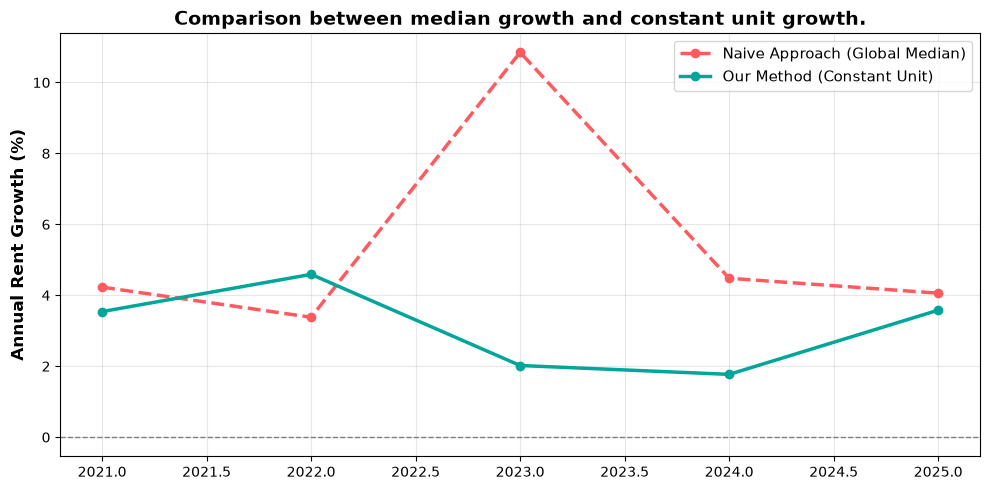

In [3]:
# --- 1. Naive Approach (Global Median) ---
naive = (leases[leases.year.between(2019, 2025)]
         .groupby("year")
         .agg(median_rent=("sRent", "median")))
naive["yoy_pct"] = (naive.median_rent.pct_change() * 100).round(2)


# --- 2. Surgical Approach (Constant Unit) ---
UNIT_KEY = ["sPropCode", "sUnitCode"]

def same_unit_growth_basic(df):
    d = df.sort_values(UNIT_KEY + ["sLeaseFrom"]).copy()
    
    # Find the previous lease for the same unit
    d["prev_price"] = d.groupby(UNIT_KEY)["sRentEffective"].shift(1)
    d["prev_date"]  = d.groupby(UNIT_KEY)["sLeaseFrom"].shift(1)
    d = d.dropna(subset=["prev_price", "prev_date"])
    
    # Keep renewals between 6 months and 2.5 years
    d["gap_years"] = (d["sLeaseFrom"] - d.prev_date).dt.days / 365.25
    d = d[d.gap_years.between(0.5, 2.5, inclusive="neither")]
    d = d[(d.prev_price > 0) & (d["sRentEffective"] > 0)]
    
    # Compound Annual Growth Rate (CAGR)
    d["growth_pct"] = ((d["sRentEffective"] / d.prev_price) ** (1 / d.gap_years) - 1) * 100
    return d

df_honest = same_unit_growth_basic(leases)
honest = (df_honest[df_honest.year.between(2021, 2025)]
          .groupby("year")
          .growth_pct.agg(median="median").round(2))


# --- 3. Creation of the Comparative Graph ---
fig, ax = plt.subplots(figsize=(10, 5))
yrs = range(2021, 2026)

# Plotting the two lines
ax.plot(yrs, naive.loc[yrs, "yoy_pct"], "o--", color="#FF5A5F", label="Naive Approach (Global Median)", lw=2.5)
ax.plot(yrs, honest.loc[yrs, "median"], "o-", color="#00A699", label="Our Method (Constant Unit)", lw=2.5)

# Design
ax.axhline(0, color="grey", lw=1, linestyle="--")
ax.set_ylabel("Annual Rent Growth (%)", fontsize=12, fontweight='bold')
ax.set_title("Comparison between median growth and constant unit growth.", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()

plt.show()


### Our Official Definition of Growth

Following these two visual demonstrations, the naive approach is definitively ruled out. For our predictive algorithm to meet Jadco's true business needs, we must measure growth isolated from noise and portfolio composition.

Here is the official definition of the target (`growth_pct`) of our predictive model:

1. **The Baseline: Effective Rent (`sRentEffective`)**
   We ignore contractual rent. We calculate the increase using the money *actually collected* once the amortization of free months and other concessions is deducted. This is the only accurate reflection of *Cash Flow*.
2. **The Comparison: Constant Unit (`sPropCode` + `sUnitCode`)**
   We compare the new rent of an apartment *strictly* with its previous lease. This completely eliminates false signals (e.g., an apparent 'increase' created by the sudden rental of luxury penthouses in a new building).
3. **Standardization: CAGR (Compound Annual Growth Rate)**
   Given that a previous lease could last 6 months as well as 24 months, the raw percentage difference is unusable. We use the CAGR to annualize each increase. Thus, the model always compares on a strict 12-month basis.


### Market Dynamics: Are all buildings equal?
Once the metric is defined, we must verify a fundamental hypothesis: Can we treat Jadco's portfolio as a single large entity, or does each building have its own reality?
The graph below plots the effective rent growth (our metric) for each building individually.


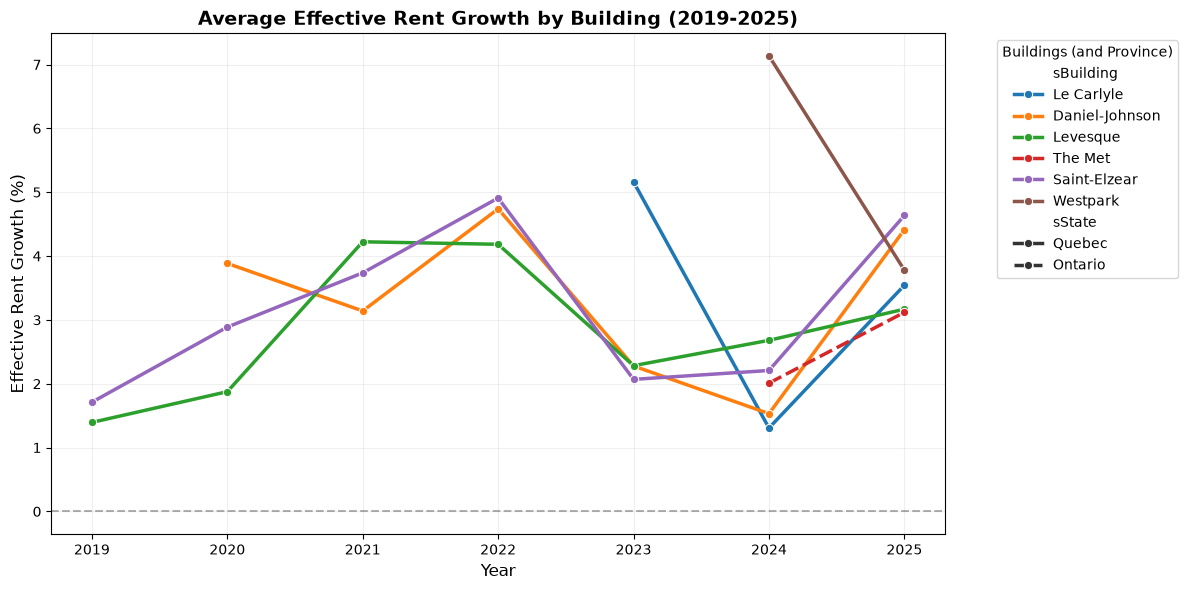

In [4]:
# --- 1. Growth calculation function (with Concession Burn-off) ---
def same_unit_growth(df, date_col="sLeaseFrom", min_gap=0.5, max_gap=2.5):
    d = df.sort_values(["sPropCode", "sUnitCode", date_col]).copy()
    
    # History of effective AND contractual rent
    d["prev_effective"] = d.groupby(["sPropCode", "sUnitCode"])["sRentEffective"].shift(1)
    d["prev_contractuel"] = d.groupby(["sPropCode", "sUnitCode"])["sRent"].shift(1)
    d["prev_date"]  = d.groupby(["sPropCode", "sUnitCode"])[date_col].shift(1)
    
    d = d.dropna(subset=["prev_effective", "prev_date"])
    
    # Time gap
    d["gap_years"] = (d[date_col] - d.prev_date).dt.days / 365.25
    d = d[d.gap_years.between(min_gap, max_gap, inclusive="neither")]
    d = d[(d.prev_effective > 0) & (d["sRentEffective"] > 0)]
    
    # Growth (Our target)
    d["growth_pct"] = ((d["sRentEffective"] / d.prev_effective) ** (1 / d.gap_years) - 1) * 100
    
    return d

# --- 2. Application of the function ---
eff_growth = same_unit_growth(leases)
eff_growth_recent = eff_growth[eff_growth["year"].between(2019, 2025)]

# --- 3. Creation of the graph ---
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=eff_growth_recent, 
    x="year", 
    y="growth_pct", 
    hue="sBuilding",   
    style="sState",    
    marker="o", 
    linewidth=2.5,
    errorbar=None,
    ax=ax
)

ax.set_title("Average Effective Rent Growth by Building (2019-2025)", fontsize=14, fontweight='bold')
ax.set_ylabel("Effective Rent Growth (%)", fontsize=12)
ax.set_xlabel("Year", fontsize=12)
plt.xticks(range(2019, 2026))
ax.axhline(0, color='black', linestyle='--', alpha=0.3)
ax.grid(alpha=0.2)

# Legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Buildings (and Province)")
plt.tight_layout()
plt.show()


**Conclusion of the building analysis:**
The importance of including the building in the model
1. The high volatility of new buildings: The curves of new buildings (Le Carlyle, Westpark) are very different. This is normal; in the marketing phase ('Lease-up'), managers give huge concessions to attract the first tenants, which temporarily distorts year-over-year growth.

2. The stability of older buildings: Established buildings (Laval) follow a clear and grouped market cycle (peak in 2022, trough in 2023-2024, rebound in 2025).

3. The case of Ontario: The Met is currently following the same trend as Quebec, showing that local market conditions dictate rents more than simple legal limits.

The graph shows that each building experiences a different reality (particularly visible with the massive dives of some buildings in 2023, while others rise). We deduce that a newly constructed building ('Lease-Up' phase) sacrifices its prices to attract volume, before making its prices jump 12 or 24 months later. This dictates our choice to include the `Is_LeaseUp` variable in our final model.


### Retention Strategy: Renewal vs New Tenant

Another crucial variable is the nature of the transaction: did the current tenant sign a renewal (`sRenewal = 1`), or was the apartment put back on the market for a new tenant (`sRenewal = 0` / Turnover)?


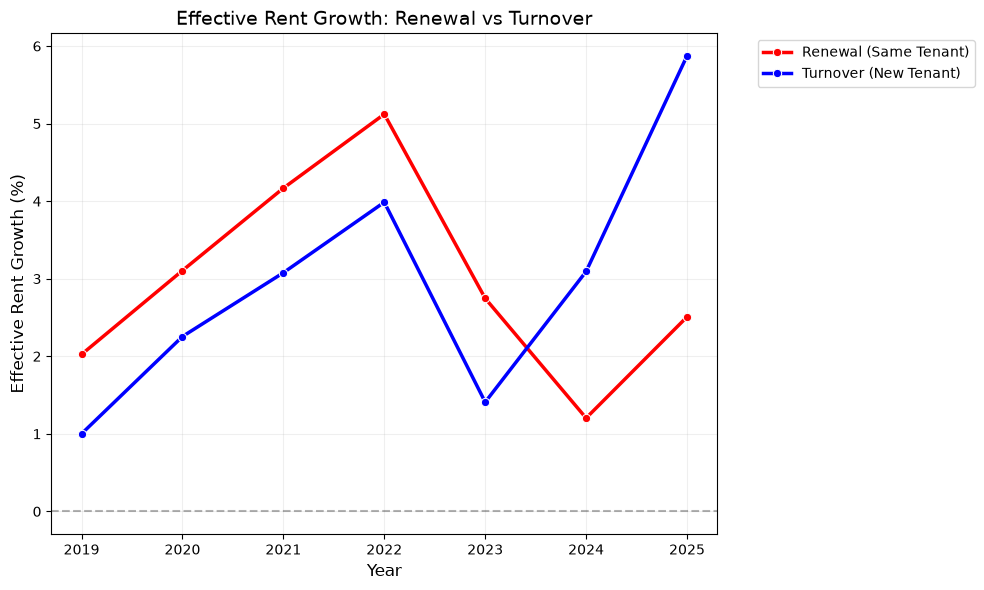

In [5]:
# Make a copy to not alter original data
plot_data = eff_growth_recent.copy()

# Create a readable column for the legend
plot_data["Transaction Type"] = plot_data["sRenewal"].map({
    1.0: "Renewal (Same Tenant)", 
    0.0: "Turnover (New Tenant)"
})

plt.figure(figsize=(10, 6))

# Graph Creation
sns.lineplot(
    data=plot_data, 
    x="year", 
    y="growth_pct", 
    hue="Transaction Type", 
    marker="o",
    linewidth=2.5,
    errorbar=None,
    palette=["red", "blue"] # Red for turnover, Blue for renewal
)

plt.title("Effective Rent Growth: Renewal vs Turnover", fontsize=14)
plt.ylabel("Effective Rent Growth (%)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.xticks(range(2019, 2026))
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.grid(alpha=0.2)

# Place legend properly
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


**Strategic conclusion and economic analysis:**

This graph is fundamental because it shows that the relationship between a renewal and a turnover is not fixed; it is dictated by the external macroeconomic context. We observe a spectacular market reversal:

1. **The tenant's market (2019 to 2023):**
Why is the growth of renewals (blue line) stronger than that of turnovers (red line)? In a more balanced market or during the fill-up phase of a luxury building, the manager is forced to offer massive concessions to attract new tenants (Turnover), which artificially pulls their effective rent down. Current tenants who renew often no longer benefit from these aggressive promotions, which mathematically makes their effective rent jump.

2. **The housing crisis (2024 to 2025):**
From 2024, the balance of power reverses. The housing shortage hits the market. Demand surpasses supply so much that landlords no longer need to offer concessions to new tenants. Result: the effective rent of turnovers (red line) explodes upwards to catch up with the real market price. At the same time, the growth of renewals (blue line) is artificially kept lower (1% to 2.5%), either to retain good tenants or to respect the guidelines of the Administrative Housing Tribunal (TAL).

**Impact for modeling:** The algorithm cannot simply memorize that 'Renewal = low'. It must cross the lease status (`sRenewal`) with the context of the year (Inflation, CMHC vacancy rate). We can also clearly see a distinction between turnover and renewal, making it essential to predict them separately.


### Further analysis that aren't statistical significative and provides nothing to the exploration

#### Floor number doesn't provide enough signal

We observe very little correlation between the effective growth of unit prices and their floor number. The only exception is the top floor of the Met building, where we see a lot of volatility.

#### The linear growth of unit prices with respect to floor area

We initially thought that unit prices might not increase linearly with floor area. Indeed, intuitively, we expect prices to grow when the unit is larger. However, we didn't know if it was on a logarithmic growth, or on a linear growth, or on an exponential growth, or something else. We initially expected the relationship to be exponential, assuming that tenants would have to pay considerably more for a slightly larger unit. However, upon plotting the data, we found that the relationship was actually linear.


### Accounting Verification: "PromoPay" and Effective Rent Audit

To guarantee the integrity of our model, we did not blindly rely on the `sRentEffective` variable. We cross-referenced the lease data with the raw history of concessions (the *PromoPay* file).

Our audit of this data validated the accounting logic of the Yardi system: free months are not imputed to a single month, but are **amortized linearly** over the entire duration of the lease to calculate the effective rent. By validating and using this exact mechanic, we ensure that our artificial intelligence trains on Jadco's true smoothed *Cash-Flow*, and not on the display contractual rent which would mask the true profitability of a unit.


### 3. External Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ══════════════════════════════════════════════════════════════════
# 1. LOAD AND PREPARE SHELTER CPI INDEX
# ══════════════════════════════════════════════════════════════════

# File has wide format with ';' separator and decimal commas
cj_raw = pd.read_csv(
    "data/external_data/conjoncture_loyer_qc.csv",
    sep=";",
    skiprows=9,       # skip 9 header lines
    header=0,
    nrows=15,         # lines 10 to 26 (useful data)
    dtype=str,
    encoding="utf-8"
)

# Keep only the 'Logement' line (line 14 = shelter CPI)
cj_raw.columns = cj_raw.columns.str.strip().str.replace('"', '')
logement = cj_raw[cj_raw.iloc[:, 0].str.contains("Logement", na=False)].iloc[0, 1:]

# Extract month names from header (ligne 10 du CSV)
header_line = cj_raw.columns[1:]  # all columns except the first

# Build CPI time series
mois_fr = {
    "janvier": "01", "fevrier": "02", "mars": "03", "avril": "04",
    "mai": "05", "juin": "06", "juillet": "07", "aout": "08",
    "septembre": "09", "octobre": "10", "novembre": "11", "decembre": "12"
}

dates_cpi = []
vals_cpi = []
for col, val in zip(header_line, logement):
    col_clean = col.strip().replace('"', '')
    val_clean = str(val).strip().replace('"', '').replace(',', '.')
    if val_clean == '' or val_clean == 'nan':
        continue
    # Extract month and year
    parts = col_clean.split()
    if len(parts) == 2 and parts[0].lower() in mois_fr:
        m = mois_fr[parts[0].lower()]
        y = parts[1]
        dates_cpi.append(pd.Timestamp(f"{y}-{m}-01"))
        vals_cpi.append(float(val_clean))

df_cpi = pd.DataFrame({"date": dates_cpi, "CPI_Logement": vals_cpi}).set_index("date")

# Calculate YoY variance (%) for Shelter CPI
df_cpi["CPI_Logement_pct_yoy"] = df_cpi["CPI_Logement"].pct_change(12) * 100

print(f"Shelter-CPI : {len(df_cpi)} months, from {df_cpi.index.min():%Y-%m} à {df_cpi.index.max():%Y-%m}")
print(df_cpi.tail())


Shelter-CPI : 49 months, from 2021-04 à 2026-07
            CPI_Logement  CPI_Logement_pct_yoy
date                                          
2026-03-01         190.1              2.867965
2026-04-01         190.2              2.644360
2026-05-01         190.1              1.984979
2026-06-01         190.2              1.711230
2026-07-01         190.3              1.819155


In [7]:
# ══════════════════════════════════════════════════════════════════
# 2. LOAD AND PREPARE CMUC (Average Constant Unit Growth)
#    from lease history
# ══════════════════════════════════════════════════════════════════

leases = pd.read_csv("data/equinoxe_lease_history.csv", skipinitialspace=True)

# Cleaning
leases["sLeaseFrom"] = pd.to_datetime(leases["sLeaseFrom"])
leases["sRentEffective"] = pd.to_numeric(leases["sRentEffective"], errors="coerce")

# Identify each unit uniquely
leases["unit_id"] = leases["sPropCode"].str.strip() + "_" + leases["sUnitCode"].str.strip()

# Sort by unit and lease sequence
leases = leases.sort_values(["unit_id", "sTermSeq"])

# Calculate constant unit growth :
# For each unit, variation of effective rent between two successive leases
leases["rent_prev"] = leases.groupby("unit_id")["sRentEffective"].shift(1)
leases["cmuc"] = (leases["sRentEffective"] - leases["rent_prev"]) / leases["rent_prev"]

# Exclude first observation (no previous)
leases_cmuc = leases.dropna(subset=["cmuc"]).copy()

# Aggregate by month (lease start date)
leases_cmuc["mois"] = leases_cmuc["sLeaseFrom"].dt.to_period("M").dt.to_timestamp()

cmuc_monthly = (
    leases_cmuc
    .groupby("mois")["cmuc"]
    .agg(["mean", "median", "count"])
    .rename(columns={"mean": "CMUC_mean", "median": "CMUC_median", "count": "n_baux"})
)

# Convert to %
cmuc_monthly["CMUC_mean_pct"] = cmuc_monthly["CMUC_mean"] * 100
cmuc_monthly["CMUC_median_pct"] = cmuc_monthly["CMUC_median"] * 100

print(f"CMUC : {len(cmuc_monthly)} months, from {cmuc_monthly.index.min():%Y-%m} à {cmuc_monthly.index.max():%Y-%m}")
print(cmuc_monthly.tail(10))


CMUC : 98 months, from 2017-09 à 2025-12
            CMUC_mean  CMUC_median  n_baux  CMUC_mean_pct  CMUC_median_pct
mois                                                                      
2025-03-01   0.033108     0.027789      51       3.310833         2.778906
2025-04-01   0.043237     0.042504      44       4.323705         4.250351
2025-05-01   0.043332     0.037038      76       4.333211         3.703799
2025-06-01   0.039058     0.035235     104       3.905793         3.523460
2025-07-01   0.038997     0.034661      91       3.899662         3.466135
2025-08-01   0.040494     0.041860      77       4.049443         4.186047
2025-09-01   0.037884     0.033944     101       3.788394         3.394435
2025-10-01   0.035233     0.036365      59       3.523332         3.636530
2025-11-01   0.034479     0.036725      57       3.447917         3.672526
2025-12-01   0.038860     0.043732      62       3.886019         4.373198



Common period : 2021-04 → 2025-11 (43 months)


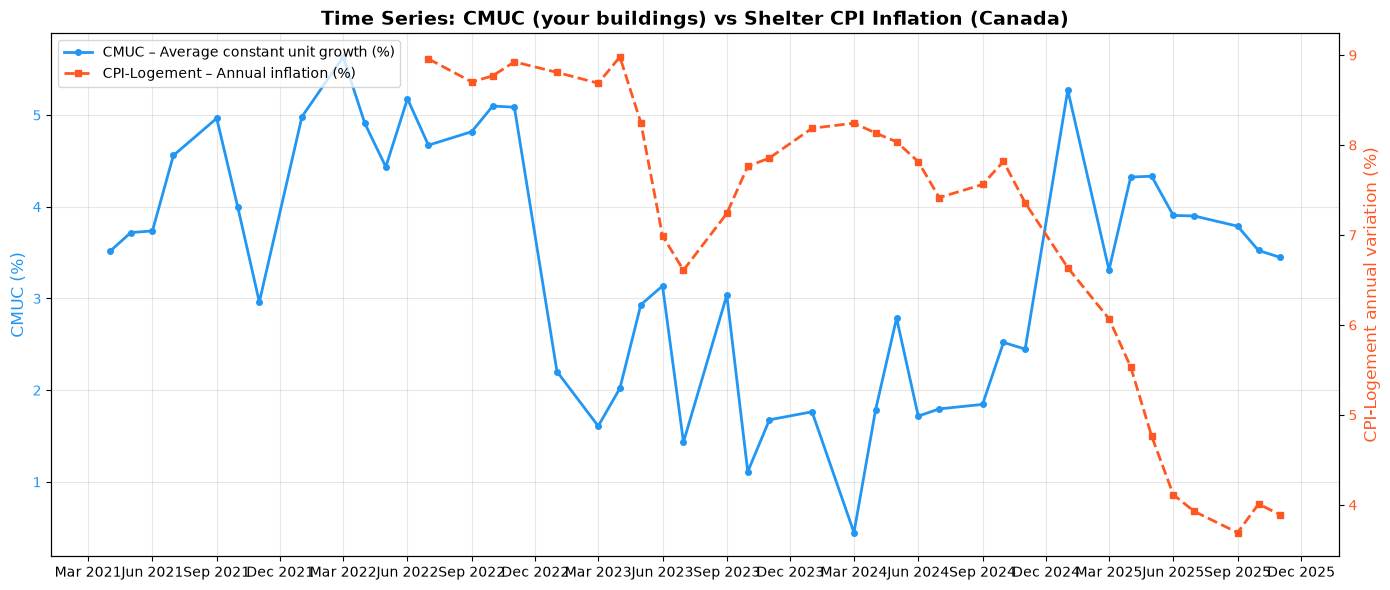

In [8]:
# ══════════════════════════════════════════════════════════════════
# 3. MERGE AND VISUALIZE BOTH SERIES
# ══════════════════════════════════════════════════════════════════

# Merge on date
df_merged = cmuc_monthly[["CMUC_mean_pct", "n_baux"]].join(
    df_cpi[["CPI_Logement_pct_yoy"]], how="inner"
)

print(f"\nCommon period : {df_merged.index.min():%Y-%m} → {df_merged.index.max():%Y-%m} ({len(df_merged)} months)")

# ─── Graph 1: Two Y axes (trend superposition) ────
fig, ax1 = plt.subplots(figsize=(14, 6))

color_cmuc = "#2196F3"
color_cpi  = "#FF5722"

# Left axis : CMUC
ax1.plot(df_merged.index, df_merged["CMUC_mean_pct"],
         color=color_cmuc, linewidth=2, marker="o", markersize=4,
         label="CMUC – Average constant unit growth (%)")
ax1.set_ylabel("CMUC (%)", color=color_cmuc, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_cmuc)
ax1.set_xlabel("")

# Right axis : CPI-Logement (annual variation)
ax2 = ax1.twinx()
ax2.plot(df_merged.index, df_merged["CPI_Logement_pct_yoy"],
         color=color_cpi, linewidth=2, linestyle="--", marker="s", markersize=4,
         label="CPI-Logement – Annual inflation (%)")
ax2.set_ylabel("CPI-Logement annual variation (%)", color=color_cpi, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color_cpi)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

ax1.set_title("Time Series: CMUC (your buildings) vs Shelter CPI Inflation (Canada)",
              fontsize=14, fontweight="bold")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax1.grid(alpha=0.3)
fig.tight_layout()
plt.show()


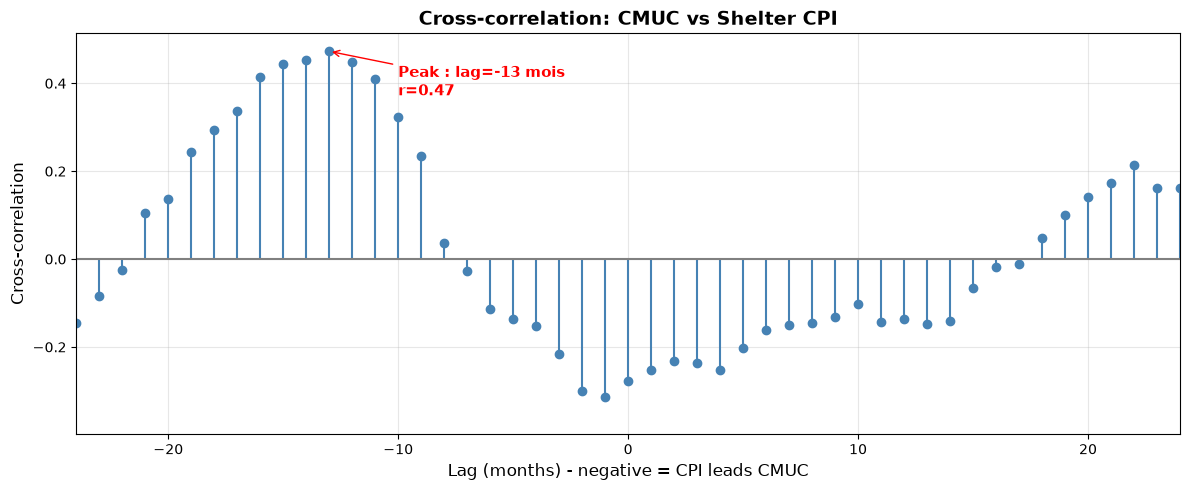


 Corrélation (lag=0) : -0.287
 Best lag        : -13 mois (r = 0.473)


In [9]:
# ─── Graph 2: Cross-correlation (lag analysis) ─────────────
# No need for scipy, using numpy directly

# Normalize both series (z-score) to compare trends
s1 = df_merged["CMUC_mean_pct"].dropna()
s2 = df_merged["CPI_Logement_pct_yoy"].dropna()

# Align
common = s1.index.intersection(s2.index)
s1 = s1.loc[common]
s2 = s2.loc[common]

if len(common) >= 6:
    s1_norm = (s1 - s1.mean()) / s1.std()
    s2_norm = (s2 - s2.mean()) / s2.std()

    # Cross correlation with numpy
    corr = np.correlate(s1_norm.values, s2_norm.values, mode="full") / len(s1_norm)
    lags = np.arange(-len(s1_norm) + 1, len(s1_norm))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.stem(lags, corr, linefmt="steelblue", markerfmt="o", basefmt="gray")
    ax.set_xlabel("Lag (months) - negative = CPI leads CMUC", fontsize=12)
    ax.set_ylabel("Cross-correlation", fontsize=12)
    ax.set_title("Cross-correlation: CMUC vs Shelter CPI", fontsize=14, fontweight="bold")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_xlim(-24, 24)

    # Annotate maximum peak
    best_lag = lags[np.argmax(corr)]
    best_corr = np.max(corr)
    ax.annotate(f"Peak : lag={best_lag} mois\nr={best_corr:.2f}",
                xy=(best_lag, best_corr),
                xytext=(best_lag + 3, best_corr - 0.1),
                arrowprops=dict(arrowstyle="->", color="red"),
                fontsize=11, color="red", fontweight="bold")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

    # Simple correlation (lag=0)
    print(f"\n Corrélation (lag=0) : {s1.corr(s2):.3f}")
    print(f" Best lag        : {best_lag} mois (r = {best_corr:.3f})")
else:
    print(" Not enough common data for cross correlation.")


### Rental prices are influenced by canadian economic indicators such as CPI

We wanted to investigate whether rental prices are influenced by Canadian economic indicators such as CPI. We therefore compared effective rent growth at the unit level with changes in the CPI index for housing using a time-series analysis. We carefully choose the CPI index for housing to be more precise on the housing market. We observe a correlation between the two series. In particular, we find the rental prices change approximately 18 months after changes in the housing CPI. This lag can be justify in several ways.

First, tenants generally sign leases for a period of at least one year. As a result, rent increases react to changes in economic conditions with a significant delay, since incerases generally occured when a lease is renewed.

Second, the rental market tends to adjust more slowly. Landlords generally adjust rents based on demand and supply, but this adjustment is not immediate. In fact, they looked the previous several months before, rather than simply responding to changes observed over the previous few weeks. they want to identify a genuine trend before changing their prices.

Third, certain rent-regulation policies in Quebec and Ontario may delay rent increases. As a result, tenants may experience increases in rent at a later date.

Fourth, CPI and the rental prices are taken at completely different times which implies at different economic situations. The market can change a lot between the CPI index being measured and the renewal or the relocation of a unit. The supply and demand can change a lot.

Finally, economic conditions are constantly changing, while some economic agents may take considerable time to react. For exemple, government actions through public investment and fiscal policies, as well as the Bank of Canada's monetary policy, can take several months to be applied and months to see the see teh effects of these actions to  materialize. Government budgets are generally annual, while the Bank of Canada's monetary policy decisions and economic reports on a regular but less frequent basis.

### CMHC Data: Capturing Local Supply and Demand
We integrated the Canada Mortgage and Housing Corporation (CMHC) dataset to capture localized market constraints. By mapping the properties to their respective Census Metropolitan Areas (Montreal, Ottawa) and joining on unit types (Bedrooms), we provided the model with the local **Vacancy Rate (`Vacancy_Rate_Pct`)**. This allows the algorithm to understand the fundamental law of supply and demand: when vacancy is low, pricing power shifts to the landlord.

### 3. Bank of Canada Interest Rate: Preventing "Macro-Overfitting"
We initially tested integrating the Bank of Canada's Policy Interest Rate to capture the buy-vs-rent dynamic. However, rigorous Walk-Forward Validation revealed that including this feature actually deteriorated our out-of-sample performance for 2025. 
Why? Because our training window (2019–2024) contains only a single macroeconomic cycle. The algorithm falsely associated the recent rate cuts in 2025 with a "soft" market (similar to 2020), completely ignoring the severe ongoing housing shortage. By purposefully **excluding** the interest rate, we prevented *macro-overfitting* and ensured our model remained robust against sudden monetary policy shifts.

## 4. Synthesis: From Business Intelligence to Machine Learning

Before moving to the predictive phase, let us summarize our answers to the core business questions based on our exhaustive data exploration. These findings directly dictate our machine learning architecture:

1. **How do we define rent growth? (The Target)**
   We proved that using global medians or contractual rents creates dangerous illusions due to portfolio mix and concessions. Our model explicitly predicts the Compound Annual Growth Rate (CAGR) of the Effective Rent on a constant-unit basis. This isolates the true economic cash-flow of Jadco's operations.
   
2. **What drives this growth? (The Features)**
   Rent growth is highly non-linear. We discovered that a unit's pricing power is dictated by a complex intersection of:
   * **Internal momentum:** The building's lifecycle (`Is_LeaseUp`), the nature of the transaction (`sRenewal`), the building it self and its location.
   * **External pressures:** The localized supply shortage (CMHC `Vacancy_Rate_Pct`) and the delayed impact of inflation (18-month lagged `CPI_Index_Shelter`).

3. **How do we predict 2026?**
   Because the relationship between these drivers is complex and non-linear (e.g., a renewal in a new building reacts differently than a turnover in an established building during an inflation peak), simple linear extrapolation is insufficient. 
   
   Therefore, we selected an **SkLearn Random forest**. We will evaluate it using a rigorous chronological Walk-Forward Validation (`backtest()` function) to ensure no future data leaks into the past, before finally extrapolating our predictions for the year 2026 (`estimate_2026()` function).


## Methodology & Architecture Decisions

### 1. Evaluating Growth at the Building Level (Comparing Unit-by-Unit)
To guarantee an appropriate comparison, we calculated the rent growth strictly on a unit-by-unit basis. However, after initially training a Random Forest model at the unit level, we found the variability was too heavily distorted by human noise (e.g., individual negotiation skills). We therefore pivoted to aggregate these individual unit growths into **building-level monthly averages**, isolating true market trends from individual variance.

### 2. Calculation of Market Gap
`Market_Gap` measures the pent-up revenue potential of a unit. We used a chronological `backward` merge to pair every lease signature with the exact `sAskingRent` advertised on the open market that same month (`Market_Gap = sAskingRent - Previous_sRentEffective`).

### 3. Calculation of Market Velocity
`Market_Velocity` measures market momentum leading up to the signature. We look back exactly 12 months to find the trailing asking rent and calculate the percentage change, telling the model if the specific unit's value is accelerating or decelerating.

### 4. Accounting for Absorption
To capture the market's absorption rate (how quickly vacant units are being leased), we engineered the **`Effective_DOM`** (Days on Market) feature. It is calculated as the difference between the signature date and the availability date. High-demand pre-leasing results in negative DOM, while stagnant vacancies yield positive DOM.

### 5. Managing Concessions

To prevent skewed data due to multiple concessions applied simultaneously on the same day, we aggregated them into a clean, deduplicated sum. We then calculated the `Concession_Ratio` to identify heavily subsidized tenants who represent significant flight-risks upon renewal.

### 6. Regulatory Frameworks: Quebec vs. Ontario
In Quebec, residential rent increases are heavily regulated by the TAL, but buildings under 5 years old are exempt (Clause F). In Ontario, any new residential unit occupied after Nov 2018 is completely exempt indefinitely. 

We engineered the `Is_Ontario` and `Is_LeaseUp` flags to differentiate these legislative regimes. Furthermore, we implemented a deterministic **`apply_regulatory_cap`** post-processing layer to legally cap predicted growth on rent-controlled properties, while explicitly bypassing the cap for exempted new builds or turnovers.

# Jadco Real Estate: Random Forest Market Pricing Model

This notebook constructs a Walk-Forward Backtesting pipeline to forecast building-level rent growth using internal lease data, concessions, and macroeconomic indicators (CMHC & CPI).

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Internal Data Engineering

Here we load the primary Jadco datasets: `Lease History`, `Asking History`, and `Concessions`.

### The 'Lease-Up' Flag
We explicitly flag properties that are in their **'Lease-Up' phase**. A building in 'Lease-Up' is a brand new development that is entering the market for the first time. 
Because these buildings are brand new, they are exempt from strict rent control (such as the TAL's Clause F in Quebec) for their first 5 years. This allows landlords to implement much more aggressive rent hikes during renewals compared to older, established buildings that are capped by the government. 

Flagging this phase allows our model to mathematically anticipate these highly aggressive rent increases without having to memorize the literal name of the building!

### 2.1 Feature Engineering: Regulation and Absorption

To ensure the model adapts to varying market conditions, two key features are engineered:
- **Is_Ontario**: A binary flag to separate buildings under Ontario LTB guidelines versus Quebec TAL guidelines. This explicitly trains the model on differing rent control dynamics.
- **Effective_DOM**: A proxy for Days on Market (Absorption) calculated as the difference between the signature date and the availability date (`sSignDate - sAvailable`). Negative values represent high-demand pre-leasing, while positive values indicate stagnant vacancies.

In [11]:
def prepare_data(data_dir="data/"):
    import pandas as pd
    import numpy as np
    
    lease_df = pd.read_csv(data_dir + "equinoxe_lease_history.csv")
    lease_df.columns = lease_df.columns.str.strip()
    asking_df = pd.read_csv(data_dir + "equinoxe_asking_history.csv")
    asking_df.columns = asking_df.columns.str.strip()

    # 1. Process Concessions
    conc_df = pd.read_csv(data_dir + 'equinoxe_concessions.csv')
    conc_df.columns = conc_df.columns.str.strip()
    conc_df['sDateFrom'] = pd.to_datetime(conc_df['sDateFrom'])
    conc_df['sAmount'] = conc_df['sAmount'].fillna(0)
    conc_sorted = conc_df.sort_values('sDateFrom')
    conc_dummies = pd.get_dummies(conc_sorted['sChargeCode'], prefix='Conc')
    conc_processed = pd.concat([conc_sorted[['hUnit', 'sDateFrom']], conc_dummies], axis=1)
    conc_amt = conc_sorted.groupby(['hUnit', 'sDateFrom'])['sAmount'].sum().reset_index()
    conc_processed = conc_processed.groupby(['hUnit', 'sDateFrom']).max().reset_index()
    conc_processed = pd.merge(conc_processed, conc_amt, on=['hUnit', 'sDateFrom'])
    conc_processed = conc_processed.sort_values('sDateFrom')

    # 2. Merge Concessions onto Leases
    lease_df['sLeaseFrom_dt'] = pd.to_datetime(lease_df['sLeaseFrom'])
    lease_sorted = lease_df.sort_values('sLeaseFrom_dt')
    lease_df = pd.merge_asof(
        lease_sorted,
        conc_processed,
        by='hUnit',
        left_on='sLeaseFrom_dt',
        right_on='sDateFrom',
        direction='backward',
        tolerance=pd.Timedelta('365D')
    )
    concession_cols = [c for c in lease_df.columns if c.startswith('Conc_')]
    lease_df[concession_cols] = lease_df[concession_cols].fillna(0).astype(int)
    lease_df['sAmount'] = lease_df['sAmount'].fillna(0)

    # 3. Flag 'Lease-Up' Strategy Buildings
    brand_new_buildings = ['Le Carlyle', 'The Met', 'Westpark']
    def is_lease_up(row):
        b = str(row['sBuilding']).strip()
        p = str(row['sPropCode']).strip()
        if b in brand_new_buildings:
            return 1
        elif b == 'Saint-Elzear' and p == 'stelz3':
            return 1
        else:
            return 0
    lease_df['Is_LeaseUp'] = lease_df.apply(is_lease_up, axis=1)
    lease_df['Is_Ontario'] = lease_df['sState'].apply(lambda x: 1 if str(x).strip() == 'Ontario' else 0)
    lease_df['sSignDate'] = pd.to_datetime(lease_df['sSignDate'], errors='coerce')
    lease_df['sAvailable'] = pd.to_datetime(lease_df['sAvailable'], errors='coerce')
    lease_df['Effective_DOM'] = (lease_df['sSignDate'] - lease_df['sAvailable']).dt.days
    lease_df['Effective_DOM'] = lease_df['Effective_DOM'].fillna(0)

    # 4. Clean up columns and parse dates
    keep_cols = ['Is_LeaseUp', 'Is_Ontario', 'Effective_DOM', 'hUnit', 'sPropCode', 'sBuilding', 'sCity', 'sState', 'sTermSeq', 'sRent', 'sRentEffective', 'sBeds', 'sBaths', 'sSqft', 'sUnitType', 'sRenewal', 'sLeaseFrom', 'sTermMonths', 'sAmount'] + concession_cols
    lease_df = lease_df[keep_cols].copy()
    lease_df['sLeaseFrom'] = pd.to_datetime(lease_df['sLeaseFrom'])
    lease_df['LeaseMonth'] = lease_df['sLeaseFrom'].dt.month.astype(str)
    lease_df['MergeMonth'] = lease_df['sLeaseFrom'].dt.to_period('M').astype(str)
    print(f"Base Lease Data Prepared: {lease_df.shape}")

    # Calculate Previous Rent & Previous Concessions
    lease_df = lease_df.sort_values(by=['hUnit', 'sTermSeq'])
    lease_df['Previous_sRentEffective'] = lease_df.groupby('hUnit')['sRentEffective'].shift(1)
    lease_df['Previous_sAmount'] = lease_df.groupby('hUnit')['sAmount'].shift(1)
    lease_df['Previous_sLeaseFrom'] = lease_df.groupby('hUnit')['sLeaseFrom'].shift(1)
    lease_df['Previous_Concession_Ratio'] = lease_df['Previous_sAmount'].abs() / (lease_df['Previous_sRentEffective'] * 12)
    lease_df['Previous_Concession_Ratio'] = lease_df['Previous_Concession_Ratio'].fillna(0)
    for col in concession_cols:
        lease_df[f'Previous_{col}'] = lease_df.groupby('hUnit')[col].shift(1)

    model_df = lease_df.dropna(subset=['Previous_sRentEffective']).copy()
    for col in concession_cols:
        model_df[f'Previous_{col}'] = model_df[f'Previous_{col}'].fillna(0).astype(int)

    model_df['gap_years'] = (model_df['sLeaseFrom'] - model_df['Previous_sLeaseFrom']).dt.days / 365.25
    model_df = model_df[model_df['gap_years'] >= 0.1].copy()
    model_df['growth_pct'] = ((model_df['sRentEffective'] / model_df['Previous_sRentEffective']) ** (1 / model_df['gap_years']) - 1) * 100

    asking_df = asking_df[['hUnit', 'sMonth', 'sAskingRent']].copy()
    asking_df['sMonth_dt'] = pd.to_datetime(asking_df['sMonth'] + '-01')
    model_df['sLeaseFrom_dt'] = pd.to_datetime(model_df['MergeMonth'] + '-01')
    model_df['sLeaseFrom_dt_minus_12m'] = model_df['sLeaseFrom_dt'] - pd.DateOffset(months=12)

    asking_sorted = asking_df.sort_values('sMonth_dt')
    model_sorted = model_df.sort_values('sLeaseFrom_dt')

    merged_df = pd.merge_asof(
        model_sorted, 
        asking_sorted, 
        by='hUnit', 
        left_on='sLeaseFrom_dt', 
        right_on='sMonth_dt', 
        direction='backward'
    )
    merged_df = pd.merge_asof(
        merged_df.sort_values('sLeaseFrom_dt_minus_12m'), 
        asking_sorted, 
        by='hUnit', 
        left_on='sLeaseFrom_dt_minus_12m', 
        right_on='sMonth_dt', 
        direction='backward',
        suffixes=('', '_12m_ago')
    )
    merged_df = merged_df.sort_values(['hUnit', 'sTermSeq'])
    merged_df['Market_Gap'] = merged_df['sAskingRent'] - merged_df['Previous_sRentEffective']
    merged_df['Market_Gap'] = merged_df['Market_Gap'].fillna(0)
    merged_df['Market_Velocity'] = (merged_df['sAskingRent'] - merged_df['sAskingRent_12m_ago']) / merged_df['sAskingRent_12m_ago']
    merged_df['Market_Velocity'] = merged_df['Market_Velocity'].fillna(0) 
    print(f"Target Variable Engineered. Valid leases: {len(merged_df)}")

    cmhc_df = pd.read_csv(data_dir + "external_data/cmhc_consolidated.csv")
    cmhc_df['Date_dt'] = pd.to_datetime(cmhc_df['Date'] + '-01')
    cmhc_sorted = cmhc_df.sort_values('Date_dt')
    cma_mapping = {'Mont-Royal': 'Montreal', 'Laval': 'Montreal', 'Pointe-Claire': 'Montreal', 'Ottawa': 'Ottawa'}
    merged_df['CMA'] = merged_df['sCity'].map(cma_mapping).fillna('Montreal')
    unit_mapping = {0: 'Studio', 1: '1 Bedroom', 2: '2 Bedroom', 3: '3 Bedroom +'}
    merged_df['Unit_Type_CMHC'] = merged_df['sBeds'].map(unit_mapping)

    merged_df = merged_df.sort_values('sLeaseFrom_dt')
    merged_df = pd.merge_asof(
        merged_df,
        cmhc_sorted,
        left_on='sLeaseFrom_dt',
        right_on='Date_dt',
        left_by=['CMA', 'Unit_Type_CMHC'],
        right_by=['City', 'Unit_Type'],
        direction='backward'
    )
    merged_df['Vacancy_Rate_Pct'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Vacancy_Rate_Pct'].transform(lambda x: x.bfill().ffill())
    merged_df['Average_Rent'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Average_Rent'].transform(lambda x: x.bfill().ffill())
    merged_df['Rent_YoY_Growth_Pct'] = merged_df.groupby(['CMA', 'Unit_Type_CMHC'])['Rent_YoY_Growth_Pct'].transform(lambda x: x.bfill().ffill())
    merged_df['CMHC_Market_Premium'] = (merged_df['Previous_sRentEffective'] - merged_df['Average_Rent']) / merged_df['Average_Rent']
    merged_df['CMHC_Market_Premium'] = merged_df['CMHC_Market_Premium'].fillna(0)

    cpi_df = pd.read_csv(data_dir + 'external_data/cpi_inflation.csv')
    cpi_df = cpi_df[cpi_df['Products and product groups'] == 'Shelter'].copy()
    cpi_df['Date_dt'] = pd.to_datetime(cpi_df['REF_DATE'] + '-01')
    cpi_df = cpi_df.sort_values('Date_dt')
    cpi_df = cpi_df[['Date_dt', 'VALUE']].rename(columns={'VALUE': 'CPI_Index_Shelter'})
    merged_df['LeaseFrom_Lagged_18m'] = merged_df['sLeaseFrom_dt'] - pd.DateOffset(months=18)
    merged_df = merged_df.sort_values('LeaseFrom_Lagged_18m')
    merged_df = pd.merge_asof(
        merged_df,
        cpi_df,
        left_on='LeaseFrom_Lagged_18m',
        right_on='Date_dt',
        direction='backward'
    )
    merged_df['CPI_Index_Shelter'] = merged_df['CPI_Index_Shelter'].bfill().ffill()
    merged_df['sBaths'] = merged_df['sBaths'].fillna(merged_df['sBaths'].median())
    merged_df['sSqft'] = merged_df['sSqft'].fillna(merged_df['sSqft'].median())
    merged_df['sTermMonths'] = merged_df['sTermMonths'].fillna(12)
    print("Macro Data Merged Successfully.")

    valid_mask = merged_df['growth_pct'].between(-25, 50)
    clean_df = merged_df[valid_mask].copy()
    clean_df['Lease_Year'] = clean_df['sLeaseFrom_dt'].dt.year
    print(f"Original unit-level rows: {len(clean_df)}")

    bldg_df = clean_df.groupby(['sPropCode', 'Lease_Year', 'LeaseMonth', 'sRenewal']).agg(
        growth_pct=('growth_pct', 'mean'),
        CPI_Index_Shelter=('CPI_Index_Shelter', 'mean'),
        Is_LeaseUp=('Is_LeaseUp', 'max'),
        Is_Ontario=('Is_Ontario', 'max'),
        Effective_DOM=('Effective_DOM', 'mean'),
        Market_Gap=('Market_Gap', 'mean'),
        Market_Velocity=('Market_Velocity', 'mean'),
        Vacancy_Rate_Pct=('Vacancy_Rate_Pct', 'mean'),
        Rent_YoY_Growth_Pct=('Rent_YoY_Growth_Pct', 'mean'),
        CMHC_Market_Premium=('CMHC_Market_Premium', 'mean'),
        Previous_sRentEffective=('Previous_sRentEffective', 'mean'),
        Previous_Concession_Ratio=('Previous_Concession_Ratio', 'mean'),
        Lease_Count=('hUnit', 'count')
    ).reset_index()

    bldg_df = bldg_df[bldg_df['Lease_Count'] >= 3].copy()
    print(f"Aggregated Building-Month rows: {len(bldg_df)}")

    features = [
        'Lease_Year', 'LeaseMonth', 'sRenewal', 'CPI_Index_Shelter', 'Is_LeaseUp', 'Is_Ontario', 'Effective_DOM', 
        'Market_Gap', 'Market_Velocity', 'Vacancy_Rate_Pct', 
        'Rent_YoY_Growth_Pct', 'CMHC_Market_Premium', 
        'Previous_sRentEffective', 'Previous_Concession_Ratio'
    ]
    X = bldg_df[features].copy()
    y = bldg_df['growth_pct']
    X = pd.get_dummies(X, columns=['LeaseMonth'], drop_first=True)
    print(f"Final aggregated dataset ready. Shape: {X.shape}")
    
    return X, y, bldg_df, features

X, y, bldg_df, features = prepare_data(data_dir="data/")


Base Lease Data Prepared: (4302, 29)
Target Variable Engineered. Valid leases: 3241
Macro Data Merged Successfully.
Original unit-level rows: 3241
Aggregated Building-Month rows: 535
Final aggregated dataset ready. Shape: (535, 24)


In [12]:
def apply_regulatory_cap(row, target_year):
    # Turnovers are completely exempt from rent control (landlord can set open market price)
    if row['sRenewal'] == 0:
        return row['Predicted_Growth']
        
    prop = str(row['sPropCode']).lower()
    
    # 1. New Construction Exemptions (Both QC and ON)
    exempt_buildings = ['metcalfe', 'carlyle', 'stelz3', 'wsp1']
    if prop in exempt_buildings:
        return row['Predicted_Growth']
        
    # 2. Quebec Rent Control (TAL)
    tal_cap = 4.0
    return min(row['Predicted_Growth'], tal_cap)


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

def backtest(X, y, bldg_df):
    target_years = [2023, 2024, 2025]
    print("Starting Walk-Forward Backtesting for Random Forest...")

    rf_results = []
    rf_models = {}

    for year in target_years:
        print(f"\n--- Backtesting Year: {year} ---")
        
        train_mask = X['Lease_Year'] < year
        test_mask = X['Lease_Year'] == year
        
        X_train = X[train_mask].drop(columns=['Lease_Year']).astype(float)
        y_train = y[train_mask]
        
        X_test = X[test_mask].drop(columns=['Lease_Year']).astype(float)
        y_test = y[test_mask]
        
        if len(X_test) == 0:
            continue
            
        rf_model = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
        rf_model.fit(X_train, y_train)
        rf_models[year] = rf_model
        
        preds = rf_model.predict(X_test)
        
        mae_overall = mean_absolute_error(y_test, preds)
        renewal_mask = X_test['sRenewal'] == 1
        turnover_mask = X_test['sRenewal'] == 0
        
        mae_renewal = mean_absolute_error(y_test[renewal_mask], preds[renewal_mask]) if renewal_mask.sum() > 0 else np.nan
        mae_turnover = mean_absolute_error(y_test[turnover_mask], preds[turnover_mask]) if turnover_mask.sum() > 0 else np.nan
        
        print(f"RF Results for {year}:")
        print(f"  -> Overall MAE  = {mae_overall:.4f}%")
        print(f"  -> Renewal MAE  = {mae_renewal:.4f}%")
        print(f"  -> Turnover MAE = {mae_turnover:.4f}%\n")
        
        rf_results.append({
            'Year': year,
            'Overall_MAE': mae_overall,
            'Renewal_MAE': mae_renewal,
            'Turnover_MAE': mae_turnover
        })

        test_bldg_data = bldg_df.loc[X_test.index].copy()
        test_bldg_data['Predicted_Growth'] = preds
        
        print(f"Detailed Forecast by Building for {year} (RF):")
        detailed_forecast = test_bldg_data.groupby(['sPropCode', 'sRenewal'])['Predicted_Growth'].mean().unstack().round(2)
        detailed_forecast.columns = ['Turnover Forecast (%)', 'Renewal Forecast (%)']

    res_df_rf = pd.DataFrame(rf_results)
    print("\n--- Average Out-of-Sample Performance (Random Forest) ---")
    print(res_df_rf.mean(numeric_only=True))
    
    return rf_models

rf_models = backtest(X, y, bldg_df)


Starting Walk-Forward Backtesting for Random Forest...

--- Backtesting Year: 2023 ---
RF Results for 2023:
  -> Overall MAE  = 2.5059%
  -> Renewal MAE  = 2.0688%
  -> Turnover MAE = 3.1459%

Detailed Forecast by Building for 2023 (RF):

--- Backtesting Year: 2024 ---
RF Results for 2024:
  -> Overall MAE  = 2.7105%
  -> Renewal MAE  = 2.7648%
  -> Turnover MAE = 2.6413%

Detailed Forecast by Building for 2024 (RF):

--- Backtesting Year: 2025 ---
RF Results for 2025:
  -> Overall MAE  = 2.1494%
  -> Renewal MAE  = 1.9809%
  -> Turnover MAE = 2.3522%

Detailed Forecast by Building for 2025 (RF):

--- Average Out-of-Sample Performance (Random Forest) ---
Year            2024.000000
Overall_MAE        2.455251
Renewal_MAE        2.271496
Turnover_MAE       2.713153
dtype: float64


1. FEATURE IMPORTANCE


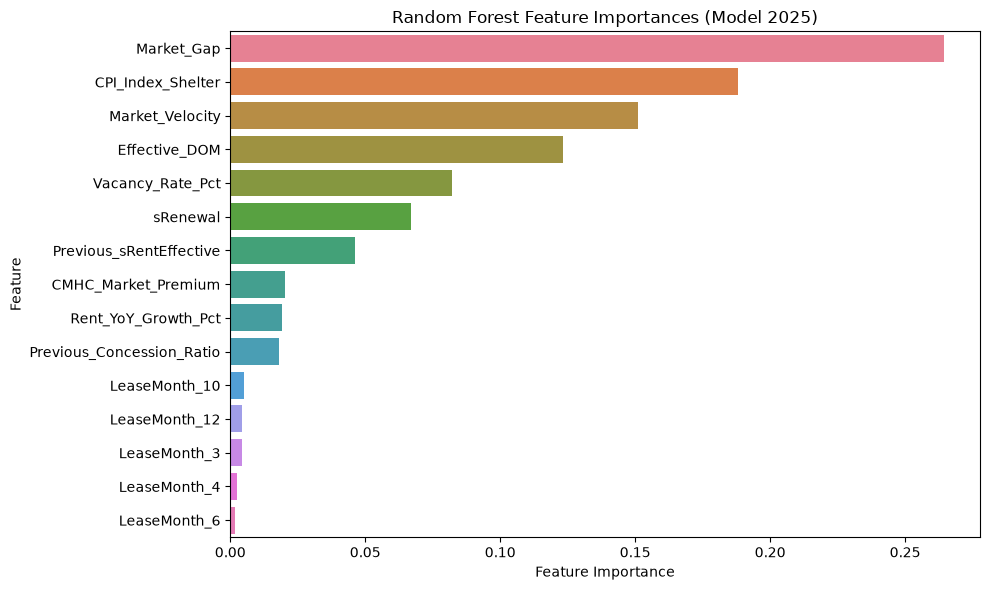


2. SHAP VALUES (Random Forest)


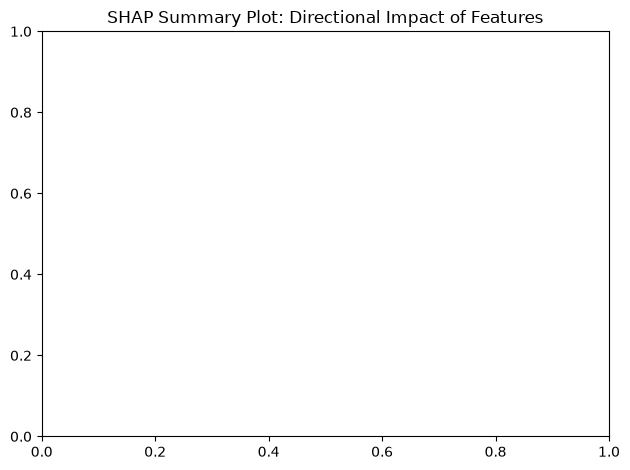


3. PARTIAL DEPENDENCE PLOTS (Random Forest)


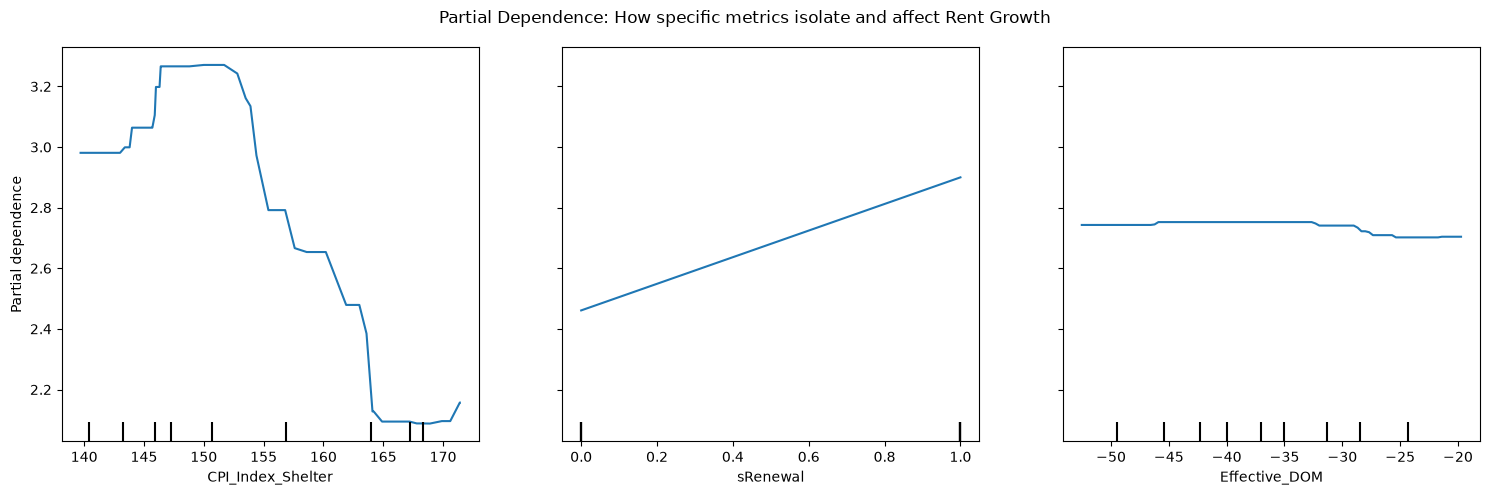

In [14]:
target_years = [2023, 2024, 2025]
train_mask = X['Lease_Year'] < 2025
X_train = X[train_mask].drop(columns=['Lease_Year']).astype(float)

# import shap
from sklearn.inspection import PartialDependenceDisplay

last_year = target_years[-1]
final_model = rf_models[last_year]

print("1. FEATURE IMPORTANCE")
imp_df = pd.DataFrame({
    'Feature': X.drop(columns=['Lease_Year']).columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='Importance', y='Feature', hue='Feature', legend=False)
plt.title(f'Random Forest Feature Importances (Model {last_year})')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

print("\n2. SHAP VALUES (Random Forest)")
# SHAP shows exactly how much each feature moved the prediction for individual buildings
# explainer = shap.TreeExplainer(final_model)
# shap_values = explainer(X_train)
# shap.summary_plot(shap_values, X_train, plot_type="dot", show=False)
plt.title('SHAP Summary Plot: Directional Impact of Features')
plt.tight_layout()
# plt.savefig('shap_summary.png', dpi=300)
plt.show()

print("\n3. PARTIAL DEPENDENCE PLOTS (Random Forest)")
# PDPs isolate a feature to show how the model reacts as that feature scales up or down
rf_final = rf_models[last_year]
features_to_plot = ['CPI_Index_Shelter', 'sRenewal', 'Effective_DOM']
fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(rf_final, X_train, features_to_plot, ax=ax)
plt.suptitle('Partial Dependence: How specific metrics isolate and affect Rent Growth')
plt.tight_layout()
plt.savefig('pdp_plots.png', dpi=300)
plt.show()


In [15]:
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

def estimate_2026(X, y, bldg_df, features):
    print("\n--- 2026 PORTFOLIO RENT GROWTH FORECAST ---")
    X_full = X.drop(columns=['Lease_Year'])
    y_full = y

    final_rf_2026 = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
    final_rf_2026.fit(X_full, y_full)

    latest_data = bldg_df.sort_values(['Lease_Year', 'LeaseMonth']).groupby(['sPropCode', 'sRenewal']).tail(1).copy()
    latest_data['Lease_Year'] = 2026

    X_2026 = latest_data[features].copy()
    X_2026 = pd.get_dummies(X_2026, columns=['LeaseMonth'], drop_first=True)
    X_2026 = X_2026.reindex(columns=X_full.columns, fill_value=0)

    latest_data['Predicted_Growth'] = final_rf_2026.predict(X_2026)
    latest_data['Predicted_2026_Growth_Pct'] = latest_data.apply(lambda row: apply_regulatory_cap(row, 2026), axis=1)

    forecast_summary = latest_data.groupby('sRenewal')['Predicted_2026_Growth_Pct'].mean().reset_index()
    forecast_summary['Type'] = forecast_summary['sRenewal'].map({0: 'Turnover', 1: 'Renewal'})

    print("Average Portfolio Forecast:")
    print(forecast_summary[['Type', 'Predicted_2026_Growth_Pct']].to_string(index=False))

    print("\nDetailed Forecast by Building:")
    detailed_forecast = latest_data.groupby(['sPropCode', 'sRenewal'])['Predicted_2026_Growth_Pct'].mean().unstack().round(2)
    detailed_forecast.columns = ['Turnover Forecast (%)', 'Renewal Forecast (%)']
    display(detailed_forecast)
    
    print("\n--- Extrapolating Missing Buildings (e.g., stelz3) ---")

    synthetic_turnover = X_2026[(latest_data['sPropCode'] == 'stelz2') & (latest_data['sRenewal'] == 0)].copy()
    synthetic_renewal = X_2026[(latest_data['sPropCode'] == 'stelz2') & (latest_data['sRenewal'] == 1)].copy()

    if not synthetic_turnover.empty and not synthetic_renewal.empty:
        if 'Is_LeaseUp' in synthetic_turnover.columns:
            synthetic_turnover['Is_LeaseUp'] = 1
            synthetic_renewal['Is_LeaseUp'] = 1
        
        stelz3_turnover_pred = final_rf_2026.predict(synthetic_turnover)[0]
        stelz3_renewal_pred = final_rf_2026.predict(synthetic_renewal)[0]
        
        stelz3_renewal_pred = apply_regulatory_cap({'sRenewal': 1, 'sPropCode': 'stelz3', 'Predicted_Growth': stelz3_renewal_pred}, 2026)
        
        print(f"Extrapolated stelz3 Turnover Forecast: {stelz3_turnover_pred:.2f}%")
        print(f"Extrapolated stelz3 Renewal Forecast:  {stelz3_renewal_pred:.2f}%")
        
        detailed_forecast.loc['stelz3'] = [stelz3_turnover_pred, stelz3_renewal_pred]
        
        print("\n===========================================")
        print("      FINAL 2026 PORTFOLIO FORECAST        ")
        print("===========================================")
    else:
        print("Could not find base location data for extrapolation.")

    display(detailed_forecast.sort_index().round(2))

estimate_2026(X, y, bldg_df, features)



--- 2026 PORTFOLIO RENT GROWTH FORECAST ---
Average Portfolio Forecast:
    Type  Predicted_2026_Growth_Pct
Turnover                   5.054177
 Renewal                   2.591105

Detailed Forecast by Building:


,Turnover Forecast (%),Renewal Forecast (%)
sPropCode,,
carlyle,4.95,3.18
dj1,6.46,3.36
dj2,5.65,2.68
levesque,4.83,1.37
metcalfe,4.75,3.05
stelz1,5.13,1.61
stelz2,3.97,2.45
wsp1,4.70,3.03



--- Extrapolating Missing Buildings (e.g., stelz3) ---
Extrapolated stelz3 Turnover Forecast: 3.97%
Extrapolated stelz3 Renewal Forecast:  2.43%

      FINAL 2026 PORTFOLIO FORECAST        


,Turnover Forecast (%),Renewal Forecast (%)
sPropCode,,
carlyle,4.95,3.18
dj1,6.46,3.36
dj2,5.65,2.68
levesque,4.83,1.37
metcalfe,4.75,3.05
stelz1,5.13,1.61
stelz2,3.97,2.45
stelz3,3.97,2.43
wsp1,4.70,3.03
